# Credit Risk: Predict probability of default (PD) and classify high-risk loans

Mounted at /content/drive

===== BASIC INFO =====
   Loan_ID Customer_Type  Annual_Income  Debt_to_Income  \
0        1     Corporate        2676791            0.47   
1        2        Retail        2740108            0.15   
2        3     Corporate        4863177            0.20   
3        4     Corporate        3383597            0.19   
4        5        Retail          95953            0.62   

   Credit_History_Length  Loan_Amount  Interest_Rate  Loan_Term_Months  \
0                     15       399593          13.39                36   
1                     23       825131          12.80                36   
2                     15        83686           6.09                48   
3                      5        77661           5.05                48   
4                     21       578535          11.02                24   

   Past_Default    PD  
0             0  0.22  
1             0  0.02  
2             0  0.18  
3             0  0.07  
4             0  0.12  

=====

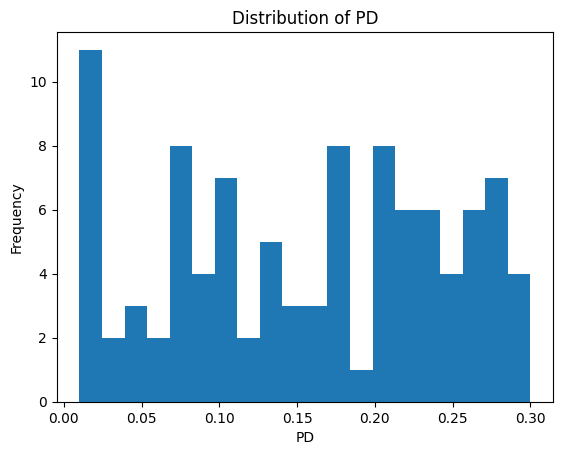


===== QUICK INSIGHTS =====
Average Loan Amount: 509767.28
Average Interest Rate: 9.0689
Average PD: 0.1572
   Loan_ID  Annual_Income  Debt_to_Income  Credit_History_Length  Loan_Amount  \
0        1        2676791            0.47                     15       399593   
1        2        2740108            0.15                     23       825131   
2        3        4863177            0.20                     15        83686   
3        4        3383597            0.19                      5        77661   
4        5          95953            0.62                     21       578535   

   Interest_Rate  Loan_Term_Months  Past_Default    PD  Monthly_Rate  \
0          13.39                36             0  0.22      0.011158   
1          12.80                36             0  0.02      0.010667   
2           6.09                48             0  0.18      0.005075   
3           5.05                48             0  0.07      0.004208   
4          11.02                24           

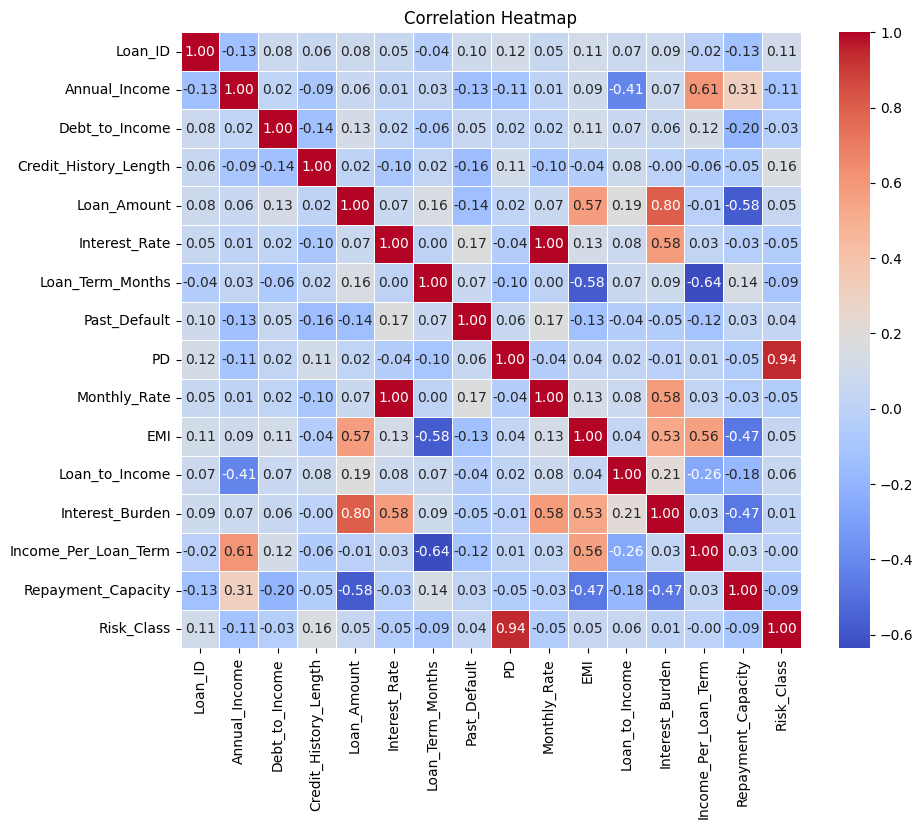


===== PD REGRESSION MODEL PERFORMANCE =====

--- RandomForest ---
MAE: 0.07625545093463473
R2: 0.11426548843477091

--- XGBoost ---
MAE: 0.06114947809278966
R2: 0.3810191840648869

===== CLASSIFICATION =====

--- RandomForest ---
Accuracy: 0.45
ROC AUC: 0.7074434389140272
Log Loss: 1.057551055045603

--- XGBoost ---
Accuracy: 0.4
ROC AUC: 0.6159502262443439
Log Loss: 1.5683985187600002


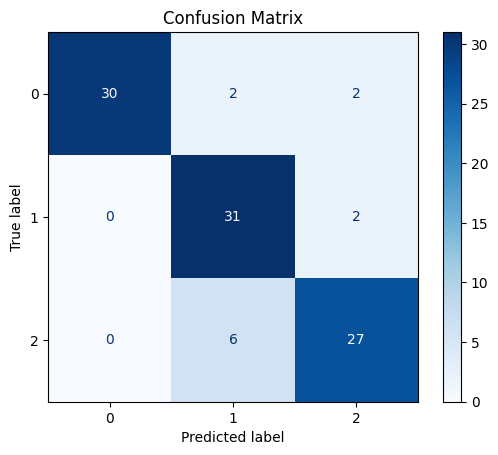

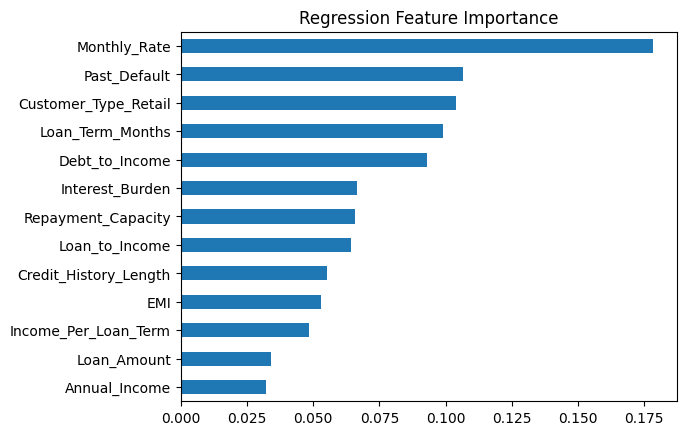

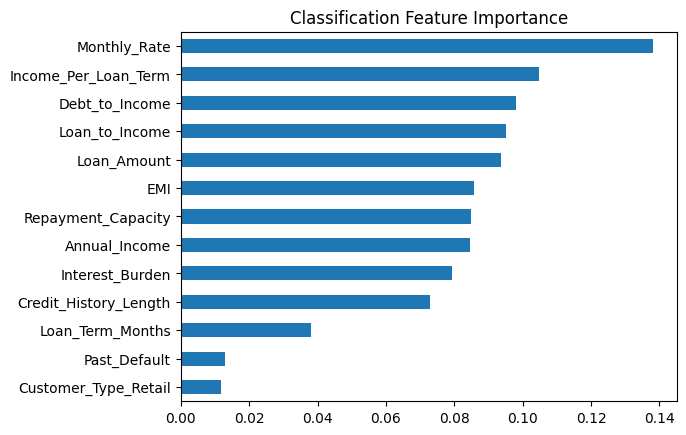


Generating SHAP plots...


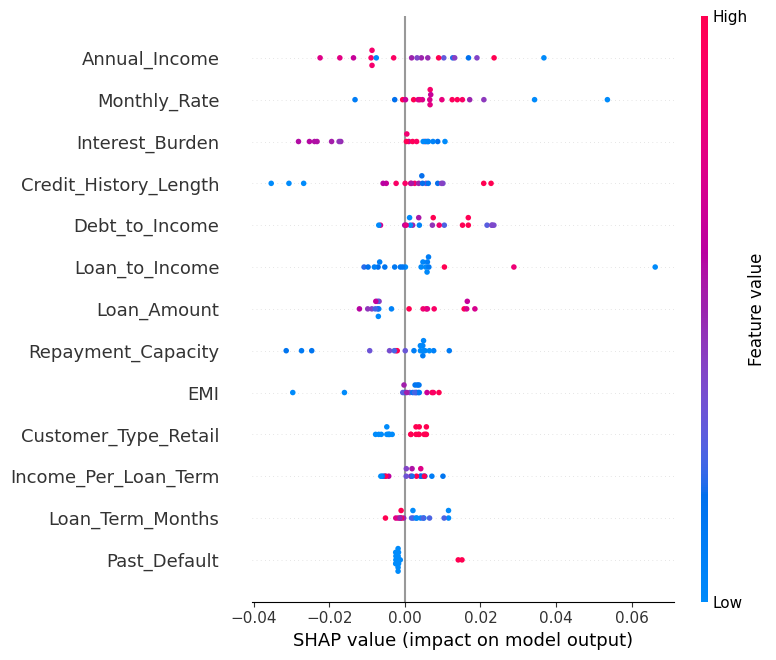

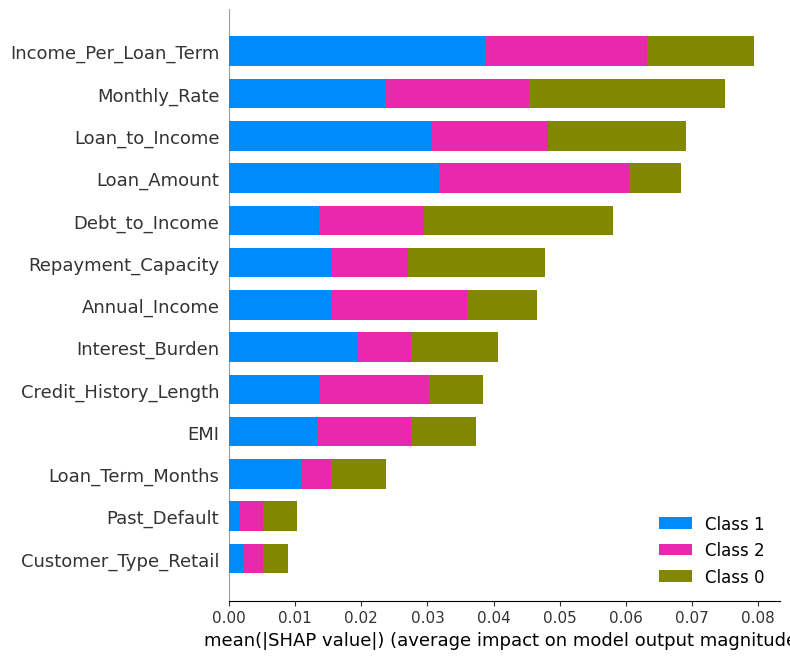


===== SUMMARY =====
Rejected: 14
Review: 23
Approved: 63

===== TOP REJECTED LOANS =====
    Loan_ID  Annual_Income  Debt_to_Income  Credit_History_Length  \
22       23        2213151            0.52                     24   
85       86        1367682            0.28                     24   
93       94        1721738            0.52                      3   
65       66        1231193            0.88                     21   
91       92        4472987            0.52                      8   
89       90        2645075            0.19                      4   
63       64        2416488            0.58                     19   
43       44        1642818            0.66                     11   
94       95        2938873            0.78                     20   
39       40        1256607            0.57                      6   

    Loan_Amount  Interest_Rate  Loan_Term_Months  Past_Default    PD  \
22       639474           3.62                48             0  0.23   
85    

In [ ]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, roc_auc_score, log_loss,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import shap


# =========================================
# 2. LOAD DATA
# =========================================
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/ml-for-finance-project/loan_portfolio.csv'
df = pd.read_csv(file_path)

print("\n===== BASIC INFO =====")
print(df.head())


# =========================================
# 3. DATA UNDERSTANDING
# =========================================
print("\n===== DATASET DESCRIPTION =====")
print(df.describe(include='all'))

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())


# =========================================
# 4. OUTLIER ANALYSIS (IQR METHOD)
# =========================================
numeric_cols = df.select_dtypes(include=np.number).columns

print("\n===== OUTLIER CHECK =====")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if not outliers.empty:
        print(f"{col}: Outliers at rows {outliers.index.tolist()}")
    else:
        print(f"{col}: No significant outliers")


# =========================================
# 5. PD DISTRIBUTION
# =========================================
print("\n===== PD DISTRIBUTION =====")

plt.figure()
plt.hist(df['PD'], bins=20)
plt.title('Distribution of PD')
plt.xlabel('PD')
plt.ylabel('Frequency')
plt.show()


# =========================================
# 6. QUICK INSIGHTS
# =========================================
print("\n===== QUICK INSIGHTS =====")
print("Average Loan Amount:", df['Loan_Amount'].mean())
print("Average Interest Rate:", df['Interest_Rate'].mean())
print("Average PD:", df['PD'].mean())


# =========================================
# 7. FEATURE ENGINEERING
# =========================================
df_mod = df.copy()

df_mod['Monthly_Rate'] = df_mod['Interest_Rate'] / (12 * 100)

df_mod['EMI'] = np.where(
    df_mod['Monthly_Rate'] == 0,
    df_mod['Loan_Amount'] / df_mod['Loan_Term_Months'],
    (
        df_mod['Loan_Amount'] *
        df_mod['Monthly_Rate'] *
        (1 + df_mod['Monthly_Rate']) ** df_mod['Loan_Term_Months']
    ) /
    ((1 + df_mod['Monthly_Rate']) ** df_mod['Loan_Term_Months'] - 1)
)

df_mod['Loan_to_Income'] = df_mod['Loan_Amount'] / (df_mod['Annual_Income'] + 1)
df_mod['Interest_Burden'] = df_mod['Loan_Amount'] * df_mod['Interest_Rate']
df_mod['Income_Per_Loan_Term'] = df_mod['Annual_Income'] / (df_mod['Loan_Term_Months'] + 1)
df_mod['Repayment_Capacity'] = df_mod['Annual_Income'] / (df_mod['EMI'] * 12 + 1)

df_mod = pd.get_dummies(df_mod, drop_first=True)

df_mod['Risk_Class'] = pd.qcut(df_mod['PD'], 3, labels=[0,1,2]).astype(int)

print(df_mod.head())

print("\n===== Risk Class Distribution ===\n")
print(df_mod['Risk_Class'].value_counts())


# =========================================
# 8. CORRELATION ANALYSIS
# =========================================
print("\n===== CORRELATION MATRIX =====")

numeric_cols = df_mod.select_dtypes(include=np.number).columns
corr = df_mod[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


# =========================================
# 9. FEATURE SELECTION
# =========================================
features = [
    col for col in df_mod.columns
    if col not in ['Loan_ID', 'PD', 'High_Risk', 'Interest_Rate', 'Risk_Class']
]

X = df_mod[features]
y = df_mod['PD']


# =========================================
# 10. TRAIN-TEST SPLIT (REGRESSION)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================================
# 11. REGRESSION MODELS
# =========================================
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=3, random_state=42)
xgb_reg = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)

rf_reg.fit(X_train, y_train)
xgb_reg.fit(X_train, y_train)


# =========================================
# 12. REGRESSION EVALUATION
# =========================================
def evaluate_regression(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

print("\n===== PD REGRESSION MODEL PERFORMANCE =====")
evaluate_regression("RandomForest", y_test, rf_reg.predict(X_test))
evaluate_regression("XGBoost", y_test, xgb_reg.predict(X_test))


# =========================================
# 13. CLASSIFICATION
# =========================================
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=3,
    random_state=42
)

y_risk = df_mod['Risk_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42
)

rf_clf.fit(X_train, y_train)
xgb_clf.fit(X_train, y_train)


# =========================================
# 14. CLASSIFICATION EVALUATION
# =========================================
def evaluate_classification(name, y_true, y_pred, y_prob):
    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted'))
    print("Log Loss:", log_loss(y_true, y_prob))

print("\n===== CLASSIFICATION =====")
evaluate_classification("RandomForest",
                        y_test,
                        rf_clf.predict(X_test),
                        rf_clf.predict_proba(X_test))

evaluate_classification("XGBoost",
                        y_test,
                        xgb_clf.predict(X_test),
                        xgb_clf.predict_proba(X_test))


# =========================================
# 15. FINAL MODELS
# =========================================
final_reg_model = xgb_reg
final_clf_model = rf_clf


# =========================================
# 16. PREDICTIONS
# =========================================
df_mod['Predicted_PD'] = final_reg_model.predict(X)
df_mod['Predicted_Risk_Class'] = final_clf_model.predict(X)


# =========================================
# 17. CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_risk, final_clf_model.predict(X))
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


# =========================================
# 18. FEATURE IMPORTANCE
# =========================================
def plot_importance(model, title):
    importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    importance.plot(kind='barh')
    plt.title(title)
    plt.show()

plot_importance(final_reg_model, "Regression Feature Importance")
plot_importance(final_clf_model, "Classification Feature Importance")


# =========================================
# 19. SHAP EXPLAINABILITY
# =========================================
print("\nGenerating SHAP plots...")

explainer = shap.Explainer(final_reg_model, X_train.astype(float))
shap.summary_plot(explainer(X_test.astype(float)), X_test)

explainer = shap.Explainer(final_clf_model, X_train.astype(float))
shap.summary_plot(explainer(X_test.astype(float)), X_test)


# =========================================
# 20. BUSINESS LOGIC
# =========================================
df_mod['Expected_Profit'] = (
    (1 - df_mod['Predicted_PD']) *
    df_mod['Loan_Amount'] *
    df_mod['Interest_Rate']
)

df_mod['Profit_Ratio'] = df_mod['Expected_Profit'] / (df_mod['Loan_Amount'] + 1)


def decision(row):
    if row['Predicted_Risk_Class'] == 2:
        if row['Profit_Ratio'] > 5 and row['Past_Default'] == 0:
            return "Review"
        else:
            return "Reject"

    elif row['Predicted_Risk_Class'] == 1:
        if row['Expected_Profit'] > 10 and row['Past_Default'] == 0:
            return "Approve"
        else:
            return "Review"

    else:
        return "Approve"


df_mod['Decision'] = df_mod.apply(decision, axis=1)


# =========================================
# 21. OUTPUT
# =========================================
rejected_loans = df_mod[df_mod['Decision'] == "Reject"].sort_values(
    by='Predicted_PD', ascending=False
)

review_loans = df_mod[df_mod['Decision'] == "Review"]
approve_loans = df_mod[df_mod['Decision'] == "Approve"]

print("\n===== SUMMARY =====")
print("Rejected:", len(rejected_loans))
print("Review:", len(review_loans))
print("Approved:", len(approve_loans))

print("\n===== TOP REJECTED LOANS =====")
print(rejected_loans.head(10))

# Fraud Detection: Flag anomalous transactions using supervised or unsupervised methods

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded transactions.csv

Dataset Shape: (200, 6)
Missing Values:
Transaction_ID      0
Customer_ID         0
Amount              0
Transaction_Type    0
Timestamp           0
Fraud_Flag          0
dtype: int64
Unique types: ['Withdrawal' 'Transfer' 'Payment']

New columns after encoding:
Index(['Type_Transfer', 'Type_Withdrawal'], dtype='object')


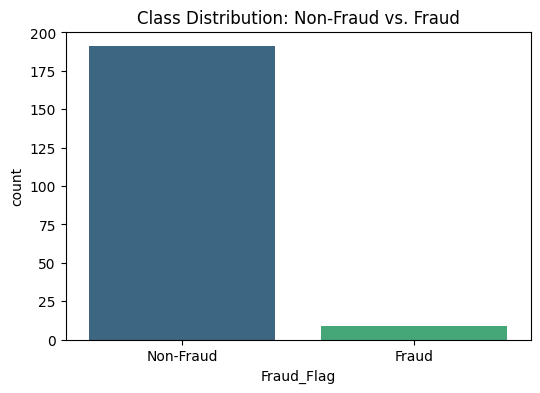

Non-Fraud: 95.50% | Fraud: 4.50%

--- Amount Analysis ---


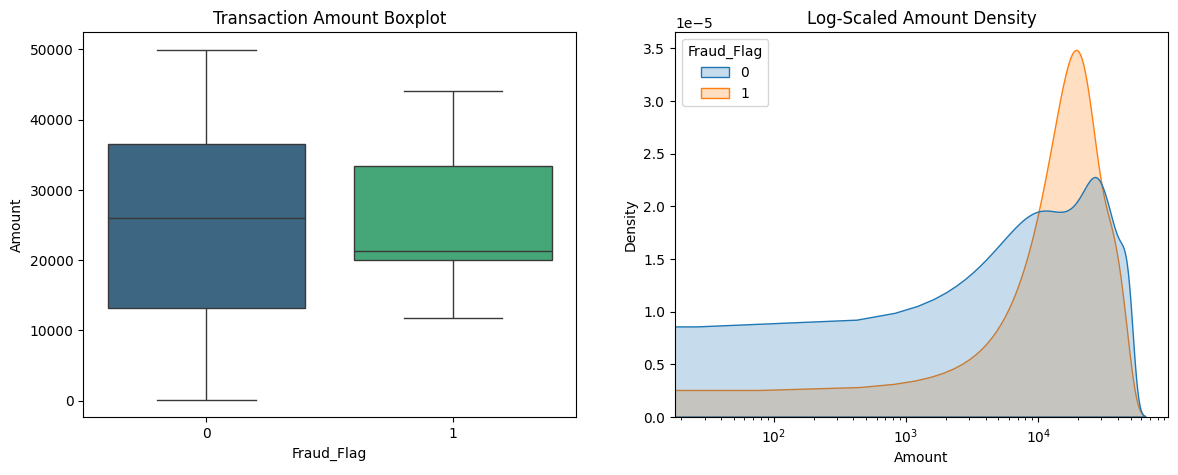


Extracted 'Hour' and 'Day_of_Week' features.


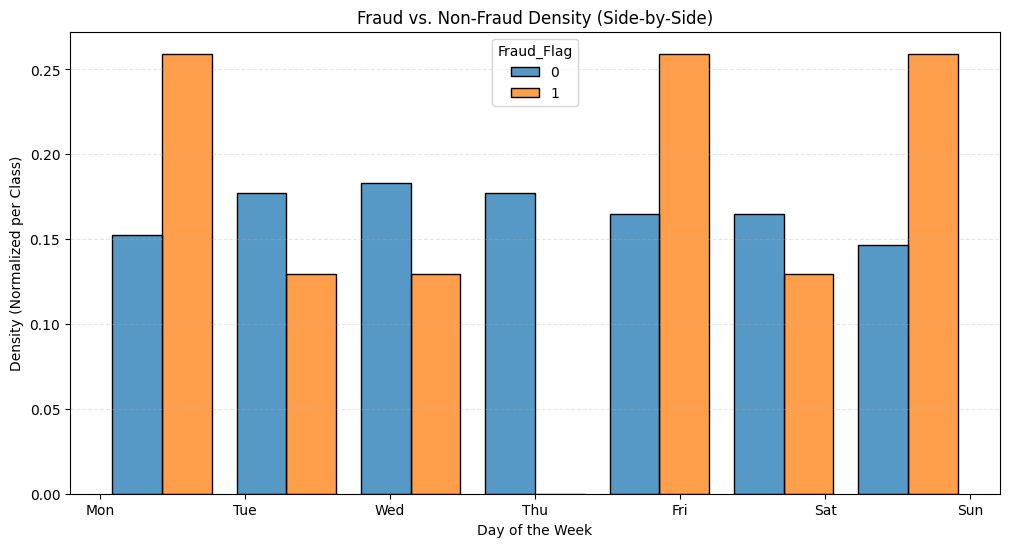

New Features Created:
   Customer_ID  Amount  Customer_Freq  Customer_Avg_Amount  Amount_vs_Avg
0           57   35200              2              19171.5       1.836059
1           16   25871              1              25871.0       1.000000
2           56   26710              4              25559.5       1.045013
3           10    5134              2              19020.5       0.269919
4           30   16711              4              13127.0       1.273025


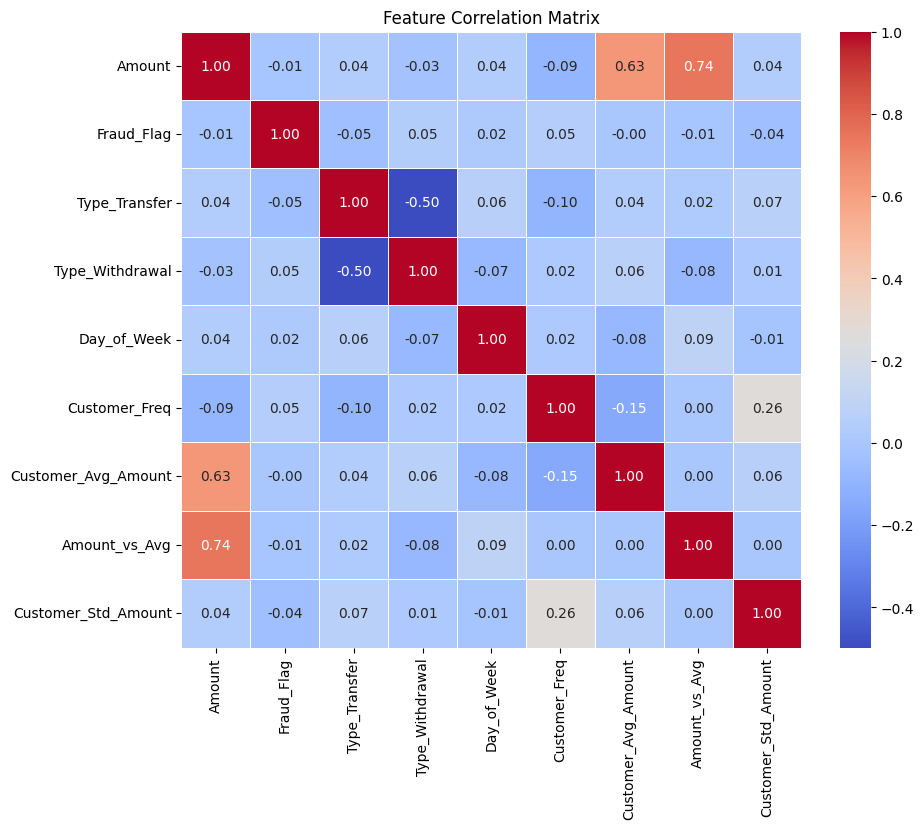


--- Mean Values by Fraud Status ---


,Amount,Type_Transfer,Type_Withdrawal,Day_of_Week,Customer_Freq,Customer_Avg_Amount,Amount_vs_Avg,Customer_Std_Amount
Fraud_Flag,,,,,,,,
0,25498.209424,0.324607,0.340314,2.947644,3.130890,25470.959250,1.000849,11533.944388
1,24709.333333,0.222222,0.444444,3.111111,3.555556,25287.642593,0.981984,9964.358893


Index(['Amount', 'Type_Transfer', 'Type_Withdrawal', 'Hour', 'Day_of_Week',
       'Customer_Freq', 'Customer_Avg_Amount', 'Amount_vs_Avg',
       'Customer_Std_Amount'],
      dtype='object')
Training Set Shape: (268, 9)
Fraud in Test Set: 3

Random Forest (Class Weight)
              precision    recall  f1-score   support

           0       0.97      0.61      0.75        57
           1       0.08      0.67      0.15         3

    accuracy                           0.62        60
   macro avg       0.53      0.64      0.45        60
weighted avg       0.93      0.62      0.72        60

ROC-AUC: 0.5322
PR-AUC (Area under Precision-Recall): 0.0546


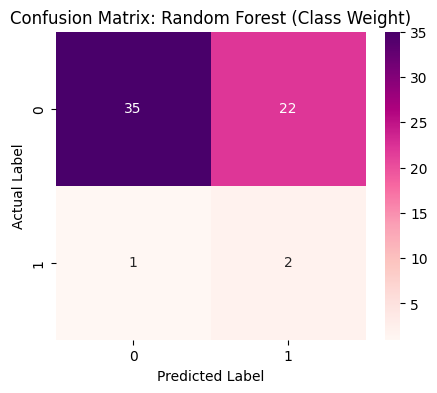


Isolation Forest (Anomaly)
              precision    recall  f1-score   support

           0       0.95      0.33      0.49        57
           1       0.05      0.67      0.09         3

    accuracy                           0.35        60
   macro avg       0.50      0.50      0.29        60
weighted avg       0.90      0.35      0.47        60

ROC-AUC: 0.5497
PR-AUC (Area under Precision-Recall): 0.0670


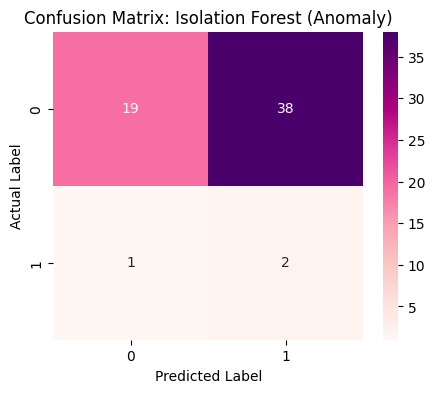

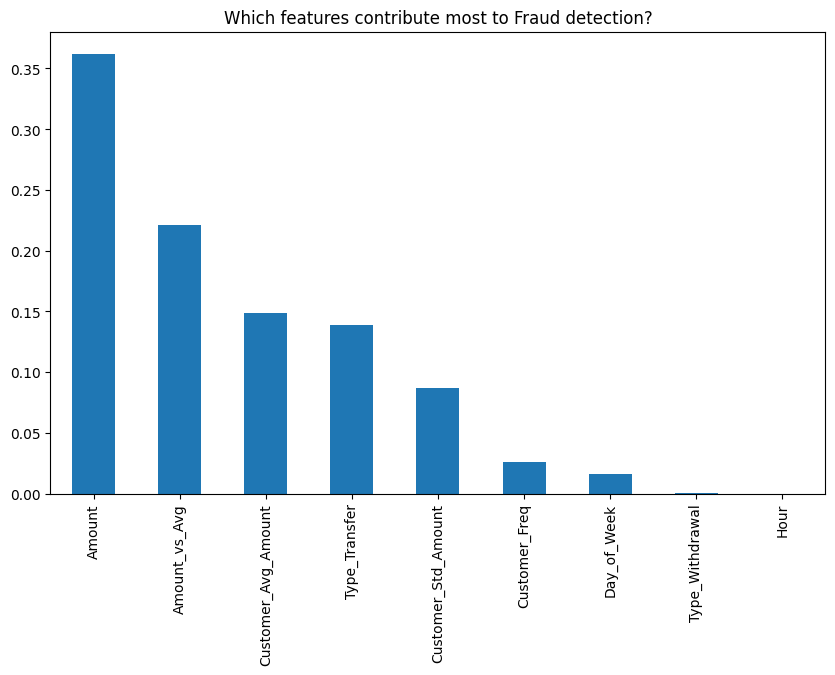


Hybrid Model (RF + Isolation Forest)
              precision    recall  f1-score   support

           0       0.99      0.78      0.87       191
           1       0.16      0.89      0.27         9

    accuracy                           0.79       200
   macro avg       0.58      0.83      0.57       200
weighted avg       0.96      0.79      0.85       200

ROC-AUC: 0.8345
PR-AUC (Area under Precision-Recall): 0.5269


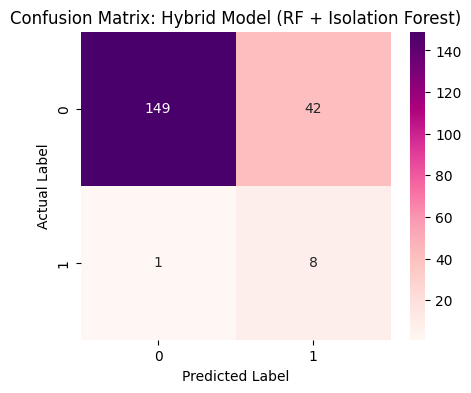

--- TOP 10 MOST SUSPICIOUS TRANSACTIONS (HYBRID MODEL) ---


,Actual_Label,Hybrid_Probability,RF_Score,IsoForest_Score,Transaction_ID,Customer_ID,Amount,Amount_vs_Avg
2,0,1,0.987471,-0.014367,3,56,26710,1.045013
5,0,1,0.997311,-0.062893,6,25,13557,0.577070
7,0,1,0.917732,0.013447,8,5,18321,0.676393
39,1,1,0.717964,0.036016,40,88,11795,0.539949
25,1,1,0.672761,-0.055953,26,15,21780,1.000000
28,0,1,0.987491,-0.035814,29,68,27133,1.252273
23,0,1,0.678001,0.034893,24,79,11989,0.759486
21,0,1,0.987247,0.026283,22,65,24910,0.706677
66,0,1,0.997483,-0.030985,67,49,28652,0.881835
58,0,1,0.997414,-0.028592,59,41,22092,0.850952



Total transactions flagged as Fraud: 50


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, precision_recall_curve, auc)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# =========================================
# 1. SETUP & DATA LOADING
# =========================================
drive.mount('/content/drive')

# Update this path as needed
file_path = '/content/drive/MyDrive/Colab Notebooks/ml-for-finance-project/transactions.csv'

try:
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    print("Successfully loaded transactions.csv")

    print(f"\nDataset Shape: {df.shape}")
    print(f"Missing Values:\n{df.isnull().sum()}")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

# =========================================
# 2. HANDLING CATEGORICAL TRANSACTION TYPES
# =========================================
print("Unique types:", df['Transaction_Type'].unique())

# Perform One-Hot Encoding
df = pd.get_dummies(df, columns=['Transaction_Type'], prefix='Type', drop_first=True)

# Convert the resulting True/False values to 1/0 integers for the models
type_cols = [col for col in df.columns if col.startswith('Type_')]
df[type_cols] = df[type_cols].astype(int)

# Now check your new columns
print("\nNew columns after encoding:")
print(df.columns[df.columns.str.startswith('Type_')])

# =========================================
# 3. TARGET CLASS DISTRIBUTION
# =========================================
if 'Fraud_Flag' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x='Fraud_Flag', data=df, hue='Fraud_Flag', palette='viridis', legend=False)
    plt.title('Class Distribution: Non-Fraud vs. Fraud')
    plt.xticks(ticks=[0, 1], labels=['Non-Fraud', 'Fraud'])
    plt.show()

    fraud_counts = df['Fraud_Flag'].value_counts(normalize=True) * 100
    print(f"Non-Fraud: {fraud_counts[0]:.2f}% | Fraud: {fraud_counts[1]:.2f}%")

else:
    print("Warning: 'Fraud_Flag' column missing.")

# =========================================
# 4. TRANSACTION AMOUNT ANALYSIS
# =========================================
if 'Amount' in df.columns and 'Fraud_Flag' in df.columns:
    print("\n--- Amount Analysis ---")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(ax=axes[0], x='Fraud_Flag', y='Amount', data=df, hue='Fraud_Flag', palette='viridis', legend=False)
    axes[0].set_title('Transaction Amount Boxplot')

    # Density plot with Log Scale to visualize overlap
    sns.kdeplot(ax=axes[1], data=df, x='Amount', hue='Fraud_Flag', fill=True, common_norm=False)
    axes[1].set_xscale('log') # Log scale helps see small vs large transaction patterns
    axes[1].set_title('Log-Scaled Amount Density')

    plt.show()

# =========================================
# 5. FEATURE ENGINEERING
# =========================================
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Hour'] = df['Timestamp'].dt.hour
    df['Day_of_Week'] = df['Timestamp'].dt.dayofweek # 0=Mon, 6=Sun

print("\nExtracted 'Hour' and 'Day_of_Week' features.")

plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x='Day_of_Week',
    hue='Fraud_Flag',
    multiple='dodge',
    shrink=0.8,
    bins=7,
    stat="density",
    common_norm=False
)
plt.title('Fraud vs. Non-Fraud Density (Side-by-Side)')
plt.xlabel('Day of the Week')
plt.ylabel('Density (Normalized per Class)')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# How many transactions has this customer made in total?
df['Customer_Freq'] = df.groupby('Customer_ID')['Transaction_ID'].transform('count')

# What is the customer's typical transaction amount?
df['Customer_Avg_Amount'] = df.groupby('Customer_ID')['Amount'].transform('mean')

# How much does THIS transaction differ from their usual average?
df['Amount_vs_Avg'] = df['Amount'] / (df['Customer_Avg_Amount'] + 1e-9) # adding small constant to avoid div by zero

# How consistent is the customer's transaction?
df['Customer_Std_Amount'] = df.groupby('Customer_ID')['Amount'].transform('std').fillna(0)

print("New Features Created:")
print(df[['Customer_ID', 'Amount', 'Customer_Freq', 'Customer_Avg_Amount', 'Amount_vs_Avg']].head())

# =========================================
# 6. CORRELATION ANALYSIS
# =========================================
cols_to_drop = ['Transaction_ID', 'Customer_ID', 'Hour']
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=[c for c in cols_to_drop if c in df.columns])

if not numeric_df.empty:
    plt.figure(figsize=(10, 8))
    correlation_matrix = numeric_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Feature Correlation Matrix')
    plt.show()

# =========================================
# 7. SUMMARY STATISTICS BY CLASS
# =========================================
if 'Fraud_Flag' in df.columns:
    print("\n--- Mean Values by Fraud Status ---")
    comparison = numeric_df.groupby('Fraud_Flag').mean()
    display(comparison)

# =========================================
# 8. TRAIN-TEST SPLIT
# =========================================
cols_to_drop = ['Fraud_Flag', 'Transaction_ID', 'Customer_ID']
X = df.select_dtypes(include=[np.number]).drop(columns=[c for c in cols_to_drop if c in df.columns])
y = df['Fraud_Flag']

print(X.columns)

# Stratify=y is critical for your 4.5% fraud distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Address the Imbalance (SMOTE)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Training Set Shape: {X_train_res.shape}")
print(f"Fraud in Test Set: {y_test.sum()}")

# =========================================
# 9. MODEL TRAINING
# =========================================
# A. RandomForest (Supervised)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight={0:1,1:100}, random_state=42)
rf_model.fit(X_train_res, y_train_res)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# B. Isolation Forest (Anomaly Detection)
# Contamination set to known fraud rate
iso_forest = IsolationForest(n_estimators=100, random_state=42)
iso_forest.fit(X_train_scaled)

# =========================================
# 10. PREDICTION & EVALUATION LOGIC
# =========================================
def evaluate_model(y_true, y_pred, y_probs, title):
    """Generates a comprehensive report and Confusion Matrix heatmap."""
    print(f"\n{'='*20}\n{title}\n{'='*20}")
    print(classification_report(y_true, y_pred))

    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recall, precision)
    roc_auc = roc_auc_score(y_true, y_probs)

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC (Area under Precision-Recall): {pr_auc:.4f}")

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu')
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# --- Process RF Results ---
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, rf_preds, rf_probs, "Random Forest (Class Weight)")

# --- Process Isolation Forest Results ---
# Map IF results: -1 (anomaly) -> 1 (fraud), 1 (normal) -> 0 (legit)
iso_raw = iso_forest.predict(X_test_scaled)
iso_preds = [1 if x == -1 else 0 for x in iso_raw]
# Higher score in decision_function means 'more normal', so we negate for 'fraud prob'
iso_probs = -iso_forest.decision_function(X_test_scaled)

evaluate_model(y_test, iso_preds, iso_probs, "Isolation Forest (Anomaly)")

# =========================================
# 11. FEATURE IMPORTANCE (For Random Forest)
# =========================================
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Which features contribute most to Fraud detection?')
plt.show()


# =========================================
# 12. HYBRID MODEL FOR FRAUD DETECTION (RF + Isolation Forest)
# =========================================
rf_final_preds = rf_model.predict(X)
rf_final_probs = rf_model.predict_proba(X)[:, 1]

X_scaled = scaler.transform(X)

iso_final_raw = iso_forest.predict(X_scaled)
iso_final_preds = [1 if x == -1 else 0 for x in iso_final_raw]
iso_final_probs = -iso_forest.decision_function(X_scaled)

# Flag it if EITHER the RF is sure OR the Isolation Forest thinks it's a huge outlier
hybrid_probs = ((rf_final_probs > 0.6) | (iso_final_probs < -0.1)).astype(int)

# Since fraud is rare, we don't use 0.5.
# We use a lower threshold to ensure we catch those small number of fraud cases.
threshold = 0.35
hybrid_preds = (hybrid_probs >= threshold).astype(int)

# Evaluate Hybrid Model
evaluate_model(y, hybrid_preds, hybrid_probs, "Hybrid Model (RF + Isolation Forest)")

# =========================================
# 13. GENERATE FRAUD WATCHLIST
# =========================================

# Create a DataFrame for the test set results
results_df = pd.DataFrame({
    'Actual_Label': y.values,
    'Hybrid_Probability': hybrid_probs,
    'RF_Score': rf_final_probs,
    'IsoForest_Score': iso_final_probs
}, index=y.index)

# Join with original data to get IDs and transaction details
# We use the index to ensure we're looking at the exact same rows from the test set
watchlist = results_df.join(df[['Transaction_ID', 'Customer_ID', 'Amount', 'Amount_vs_Avg']])

# Sort by the highest probability of fraud
watchlist = watchlist.sort_values(by='Hybrid_Probability', ascending=False)

# Display the Top 10 most suspicious transactions
print("--- TOP 10 MOST SUSPICIOUS TRANSACTIONS (HYBRID MODEL) ---")
display(watchlist.head(10))

# Filter specifically for what the model flagged (Hybrid_Probability > threshold)
flagged_transactions = watchlist[watchlist['Hybrid_Probability'] >= threshold]
print(f"\nTotal transactions flagged as Fraud: {len(flagged_transactions)}")